# Using UMAP to Reduce Inference Output

[UMAP](https://umap-learn.readthedocs.io) (Uniform Manifold Approximation and Projection) is a
dimensionality-reduction algorithm that projects high-dimensional data into 2 or 3 dimensions
while preserving local structure. This makes it ideal for visualizing the latent
space learned by an unsupervised model.

In this notebook we will:

1. Train a simple autoencoder on random data.
2. Run inference to obtain latent-space representations.
3. Apply UMAP to reduce those representations to **2D**.
4. Load and plot the UMAP output.
5. Show how to switch to **3D** output.

## 1. Setup

Create a Hyrax instance and configure it to use the built-in
``HyraxAutoencoder`` model with the ``HyraxRandomDataset``.
The random dataset lets us run the full pipeline quickly without
downloading real data.

In [1]:
from hyrax import Hyrax
from hyrax.config_utils import find_most_recent_results_dir

h = Hyrax()

In [2]:
# Use an autoencoder (unsupervised) so inference produces a latent vector.
h.set_config("model.name", "HyraxAutoencoder")

# Point at the random dataset — no download required.
data_request = {
    "train": {
        "data": {
            "dataset_class": "HyraxRandomDataset",
            "data_location": ".",
            "fields": ["image"],
            "primary_id_field": "object_id",
            "split_fraction": 1.0,
        },
    },
    "infer": {
        "data": {
            "dataset_class": "HyraxRandomDataset",
            "data_location": ".",
            "fields": ["image"],
            "primary_id_field": "object_id",
        },
    },
}
h.set_config("data_request", data_request)

# Train for just 1 epoch to keep things fast.
h.set_config("train.epochs", 1)

## 2. Train and Infer

Train the autoencoder and then run inference to produce
latent-space representations for every item in the dataset.

In [ ]:
model = h.train()
inference_results = h.infer()

## 3. Run UMAP (2D)

By default Hyrax reduces to **2 components** (``n_components = 2``).
Calling ``h.umap()`` fits a UMAP model on a sample of the inference
output, then transforms the entire dataset.

In [4]:
umap_results = h.umap()

[2026-04-23 13:56:12,791 hyrax.verbs.umap:INFO] Saving UMAP results to /Users/qiyuwang/Desktop/hyrax/docs/pre_executed/results/20260423-135612-umap-Ides
[2026-04-23 13:56:12,795 hyrax.verbs.umap:INFO] Fitting the UMAP
[2026-04-23 13:56:15,561 hyrax.verbs.umap:INFO] Saving fitted UMAP Reducer


Creating lower dimensional representation using UMAP::   0%|          | 0/1 [00:00<?, ?it/s]

[2026-04-23T20:56:16Z WARN  lance::dataset::write::insert] No existing dataset at /Users/qiyuwang/Desktop/hyrax/docs/pre_executed/results/20260423-135612-umap-Ides/lance_db/results.lance, it will be created
[2026-04-23 13:56:16,845 hyrax.datasets.result_dataset:INFO] Optimizing Lance table after 1 batches
[2026-04-23 13:56:16,847 hyrax.datasets.result_dataset:INFO] Lance table optimization complete
[2026-04-23 13:56:16,847 hyrax.verbs.umap:INFO] Finished transforming all data through UMAP


``h.umap()`` returns a ``ResultDataset`` that you can index directly.
Each element is a NumPy array with shape ``(n_components,)``.

In [5]:
import numpy as np

# Stack all UMAP embeddings into a single array.
embeddings = np.array([umap_results[i] for i in range(len(umap_results))])
print(f"Shape: {embeddings.shape}  (samples × components)")

Shape: (100, 2)  (samples × components)


## 4. Plot the 2D Embedding

A quick scatter plot of the two UMAP dimensions.

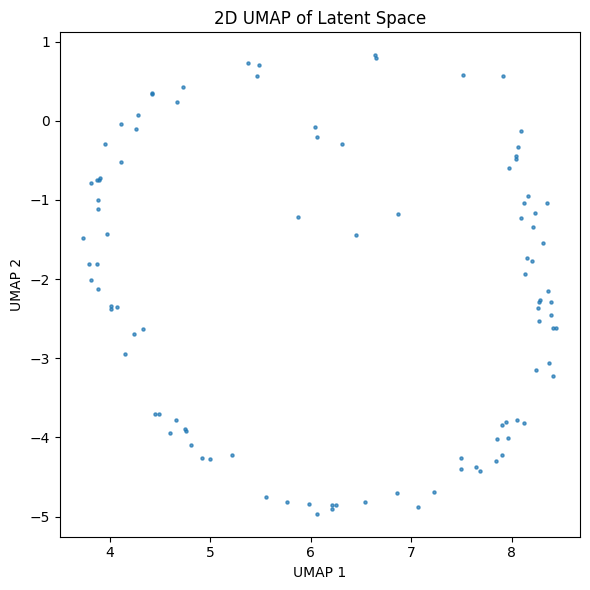

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(embeddings[:, 0], embeddings[:, 1], s=5, alpha=0.7)
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("2D UMAP of Latent Space")
plt.tight_layout()
plt.show()

## 5. Switch to 3D

To produce a 3-dimensional embedding instead, set
``n_components`` to 3 before calling ``h.umap()`` again.

In [7]:
h.set_config("umap.UMAP.n_components", 3)
umap_results_3d = h.umap()

# save the path for loading the model
result_dir_3d = find_most_recent_results_dir(h.config, "umap")

[2026-04-23 13:56:17,052 hyrax.verbs.umap:INFO] Saving UMAP results to /Users/qiyuwang/Desktop/hyrax/docs/pre_executed/results/20260423-135617-umap-GMwL
[2026-04-23 13:56:17,054 hyrax.verbs.umap:INFO] Fitting the UMAP
[2026-04-23 13:56:17,113 hyrax.verbs.umap:INFO] Saving fitted UMAP Reducer


Creating lower dimensional representation using UMAP::   0%|          | 0/1 [00:00<?, ?it/s]

[2026-04-23T20:56:17Z WARN  lance::dataset::write::insert] No existing dataset at /Users/qiyuwang/Desktop/hyrax/docs/pre_executed/results/20260423-135617-umap-GMwL/lance_db/results.lance, it will be created
[2026-04-23 13:56:17,287 hyrax.datasets.result_dataset:INFO] Optimizing Lance table after 1 batches
[2026-04-23 13:56:17,288 hyrax.datasets.result_dataset:INFO] Lance table optimization complete
[2026-04-23 13:56:17,288 hyrax.verbs.umap:INFO] Finished transforming all data through UMAP


Shape: (100, 3)  (samples × components)


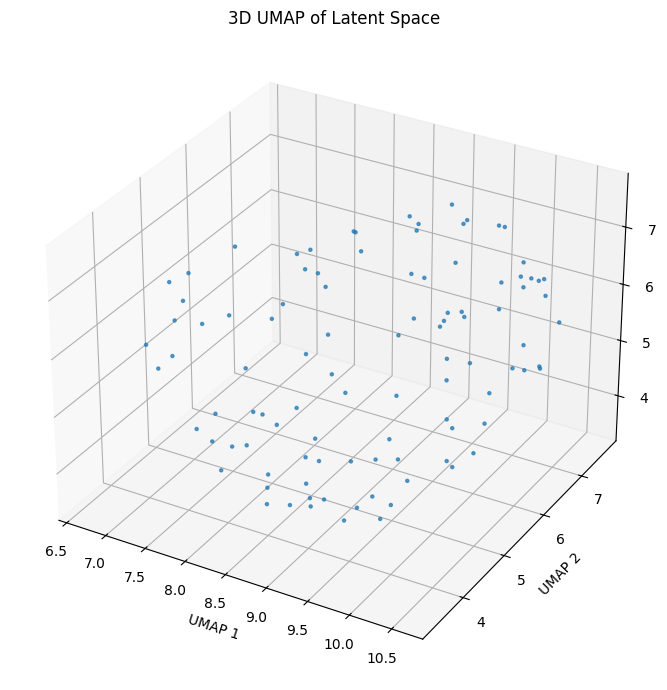

In [8]:
embeddings_3d = np.array([umap_results_3d[i] for i in range(len(umap_results_3d))])
print(f"Shape: {embeddings_3d.shape}  (samples × components)")

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(embeddings_3d[:, 0], embeddings_3d[:, 1], embeddings_3d[:, 2], s=5, alpha=0.7)
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_zlabel("UMAP 3")
ax.set_title("3D UMAP of Latent Space")
plt.tight_layout()
plt.show()

## 6. Loading pre-exisiting UMAP model


When running the `umap` verb, the trained reducer is saved in the results directory as *./umap.pickle*. We can reuse a previously trained UMAP reducer model to ensure consistent results and faster workflow.

To do this, pass the saved model path via the `model_path` argument:=

In [9]:
umap_results_load = h.umap(model_path=result_dir_3d / "umap.pickle")

[2026-04-23 13:56:17,376 hyrax.verbs.umap:INFO] Saving UMAP results to /Users/qiyuwang/Desktop/hyrax/docs/pre_executed/results/20260423-135617-umap-ks9o
[2026-04-23 13:56:17,380 hyrax.verbs.umap:INFO] Loading pre-existing UMAP model from /Users/qiyuwang/Desktop/hyrax/docs/pre_executed/results/20260423-135617-umap-GMwL/umap.pickle


Creating lower dimensional representation using UMAP::   0%|          | 0/1 [00:00<?, ?it/s]

[2026-04-23T20:56:17Z WARN  lance::dataset::write::insert] No existing dataset at /Users/qiyuwang/Desktop/hyrax/docs/pre_executed/results/20260423-135617-umap-ks9o/lance_db/results.lance, it will be created
[2026-04-23 13:56:17,564 hyrax.datasets.result_dataset:INFO] Optimizing Lance table after 1 batches
[2026-04-23 13:56:17,565 hyrax.datasets.result_dataset:INFO] Lance table optimization complete
[2026-04-23 13:56:17,565 hyrax.verbs.umap:INFO] Finished transforming all data through UMAP


The resulting shape should be the same as the 3D result. 

In [10]:
# Stack all UMAP embeddings into a single array.
embeddings_3d_load = np.array([umap_results_load[i] for i in range(len(umap_results_load))])
print(f"Shape: {embeddings_3d_load.shape}  (samples × components)")

Shape: (100, 3)  (samples × components)


It is also possible to specify a `model_path` directly in the configuration. If it is set, running the `umap` verb will automatically load and use the existing reducer.

This allows us to reuse a saved model without passing the path explicitly each time.

In [11]:
# set the model_path in config
h.set_config("umap.model_path", str(result_dir_3d / "umap.pickle"))
umap_results_load_config = h.umap()

# Stack all UMAP embeddings into a single array.
embeddings_3d_load_config = np.array(
    [umap_results_load_config[i] for i in range(len(umap_results_load_config))]
)
print(f"Shape: {embeddings_3d_load_config.shape}  (samples × components)")

[2026-04-23 13:56:17,616 hyrax.verbs.umap:INFO] Saving UMAP results to /Users/qiyuwang/Desktop/hyrax/docs/pre_executed/results/20260423-135617-umap-Wugy
[2026-04-23 13:56:17,618 hyrax.verbs.umap:INFO] Loading pre-existing UMAP model from /Users/qiyuwang/Desktop/hyrax/docs/pre_executed/results/20260423-135617-umap-GMwL/umap.pickle


Creating lower dimensional representation using UMAP::   0%|          | 0/1 [00:00<?, ?it/s]

[2026-04-23T20:56:17Z WARN  lance::dataset::write::insert] No existing dataset at /Users/qiyuwang/Desktop/hyrax/docs/pre_executed/results/20260423-135617-umap-Wugy/lance_db/results.lance, it will be created
[2026-04-23 13:56:17,780 hyrax.datasets.result_dataset:INFO] Optimizing Lance table after 1 batches
[2026-04-23 13:56:17,781 hyrax.datasets.result_dataset:INFO] Lance table optimization complete
[2026-04-23 13:56:17,781 hyrax.verbs.umap:INFO] Finished transforming all data through UMAP


Shape: (100, 3)  (samples × components)


Basic checks (e.g., file validity and dimensions compatibility) are handled automatically, but it is important to check that the provided model is meaningful for current dataset and task.

## Key Configuration Options

All UMAP settings live under the ``[umap]`` section of the Hyrax config.
The most commonly adjusted parameters are:

| Config key | Default | Description |
|---|---|---|
| ``umap.UMAP.n_components`` | 2 | Number of output dimensions (2 or 3). |
| ``umap.UMAP.n_neighbors`` | 15 | Balances local vs. global structure. |
| ``umap.fit_sample_size`` | 1024 | Number of points used to fit the UMAP model. |
| ``umap.parallel`` | false | Use multiprocessing during the transform step. |
| ``umap.model_path`` | false | Path to a pre-existing umap reducer model. |

See the [UMAP documentation](https://umap-learn.readthedocs.io/en/latest/parameters.html)
for the full list of parameters you can pass under ``umap.UMAP``.